In [1]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn import set_config
set_config(display="diagram")
# import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.compose import ColumnTransformer

# Import necessary libraries
from sklearn.impute import SimpleImputer    
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# import k-nearest neighbors
from sklearn.neighbors import KNeighborsClassifier

# import decision tree classifier
from sklearn.tree import DecisionTreeClassifier

# import random forest classifier
from sklearn.ensemble import RandomForestClassifier
# import gradient boosting classifier
from sklearn.ensemble import GradientBoostingClassifier
# import support vector classifier
from sklearn.svm import SVC


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### **Comparing the performance of different ML classifiers**  
This notebook will compare the performance of different ML classifiers (e.g. k-nearest neighbors, logistic regression, decision trees, and support vector machines). We will use the Bank marketing dataset provided from the UC Irvine Machine Learning Repository. 

# **Business understanding**

The business goal is to find a model that can explain success of a contact, i.e. if the client subscribes the deposit. Using the Bank marketing dataset, I will do some analysis to determine which factors drive the success of a marketing campaign. I will perform exploratory data analysis and build Machine Learning models to find the key drivers of a marketing campaign. I will also build multiple models with different ML classifiers (e.g. k-nearest neighbors, logistic regression, decision trees, and support vector machines) to find the best one for this task.

# **Data Understanding**

In this section I will explore the vehicles dataset to understand the fpllowing aspects:

* **Data types:** how many variables are there? What data types? Are there only numeric variables or also categorigal ones?  
* **data quality:** How many missing values are there? How many variables have a single value for all rows?
* **Correlations:** Which variables are correlated with each other or with price?
* **Data distributions:** What is the distribution of the variables? Which of them are skewed?
* **Outliers:** Are there aany outliers in the dataset? If so, how do we handle them?





In [2]:
# df = pd.read_csv('data/bank-additional-full.csv')

# Try reading the file with on_bad_lines='skip' to skip problematic lines
df = pd.read_csv('data/diabetes_binary_health_indicators_BRFSS2015.csv', on_bad_lines='skip')

In [3]:
df.shape

(253680, 22)

In [4]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [6]:
# show missing variables
df.isna().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [7]:
df = df.dropna()
df.shape



(253680, 22)

In [9]:
# Find out if any variable has the same value for all rows
df.nunique()


Diabetes_binary          2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64

In [10]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## Show distributions

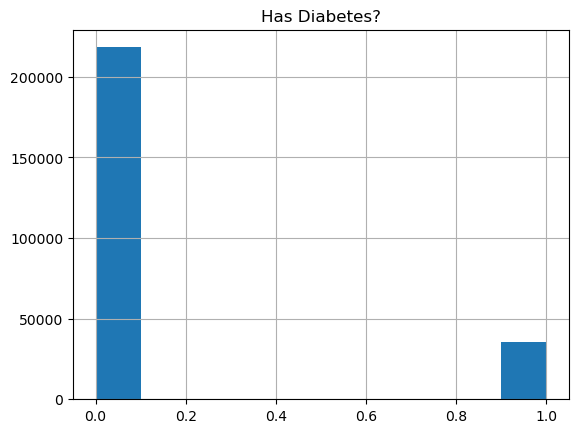

In [11]:
df['Diabetes_binary'].hist()
plt.title('Has Diabetes?')
plt.show()

In [12]:
# show the rate of diabtetes in the dataset
diabetes_rate = df['Diabetes_binary'].value_counts(normalize=True)
print("Rate of Diabetes:")
print(diabetes_rate)

Rate of Diabetes:
Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64


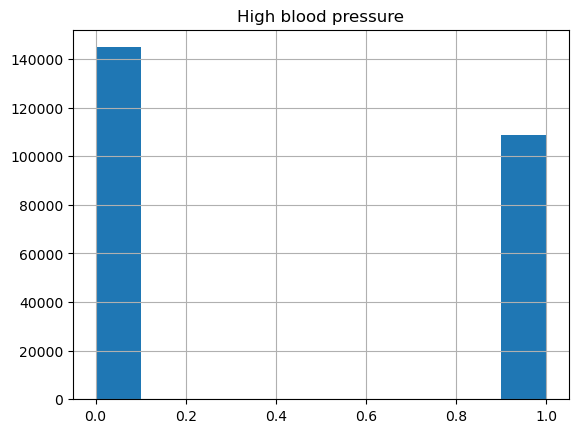

In [13]:
# plot the histogram of High bloodpressure
df['HighBP'].hist()
plt.title('High blood pressure')
plt.show()



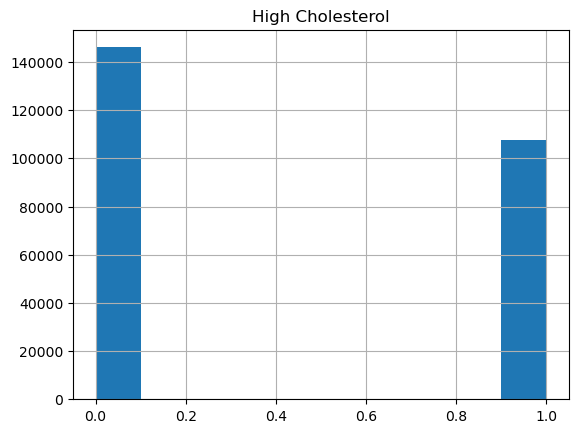

In [14]:
# plot the histogram of High Cholesterol    
df['HighChol'].hist()
plt.title('High Cholesterol')
plt.show()



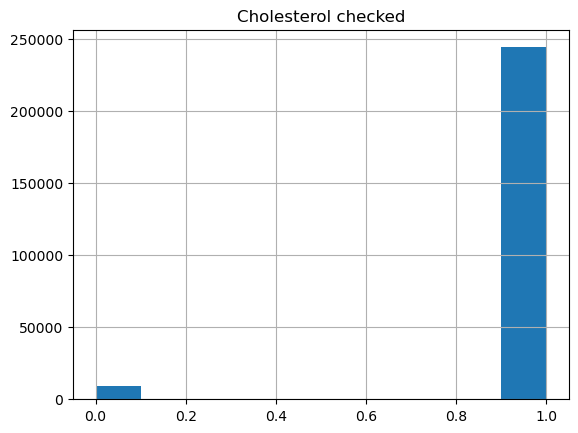

In [15]:
# plot the histogram of cholesterol checked
df['CholCheck'].hist()
plt.title('Cholesterol checked')
plt.show()

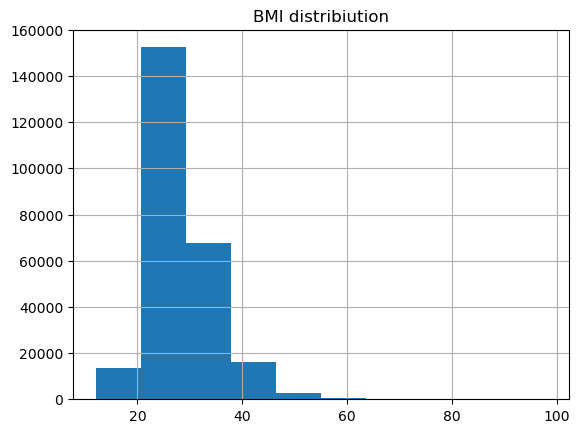

In [17]:
# plot the histogram of BMI
df['BMI'].hist()
plt.title('BMI distribiution')
plt.show()

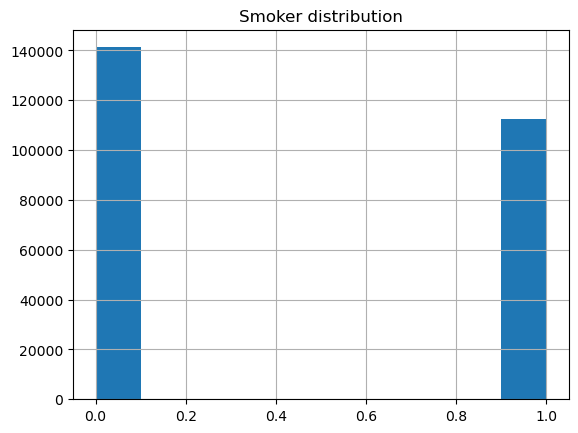

In [18]:
# plot the histogram of smoking
df['Smoker'].hist()
plt.title('Smoker distribution')
plt.show()




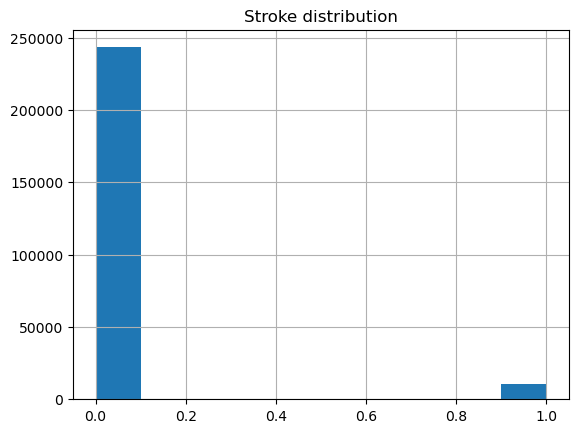

In [19]:
# plot the histogram of stroke
df['Stroke'].hist()
plt.title('Stroke distribution')
plt.show()


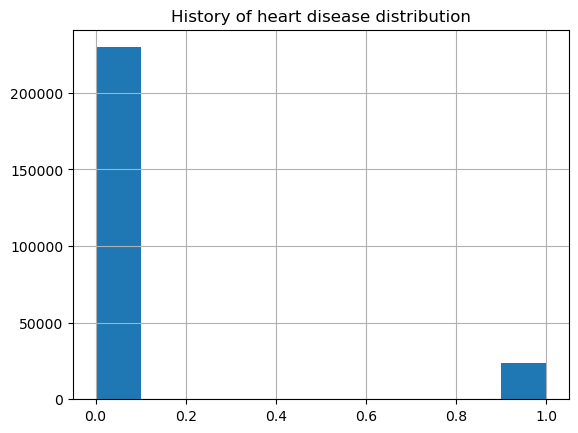

In [20]:
# plot the histogram of history of heart disease
df['HeartDiseaseorAttack'].hist()
plt.title('History of heart disease distribution')
plt.show()

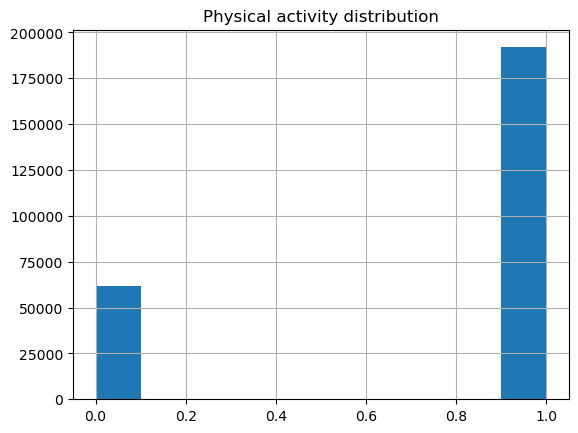

In [21]:
# plot the histogram of physical activity
df['PhysActivity'].hist()
plt.title('Physical activity distribution')
plt.show()

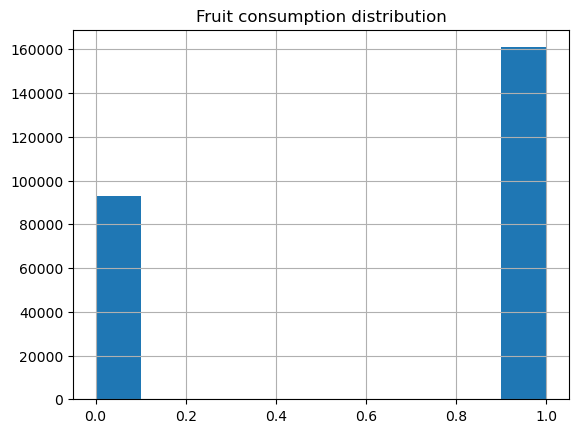

In [22]:
# plot the histogram of fruit consumption
df['Fruits'].hist()
plt.title('Fruit consumption distribution')
plt.show()

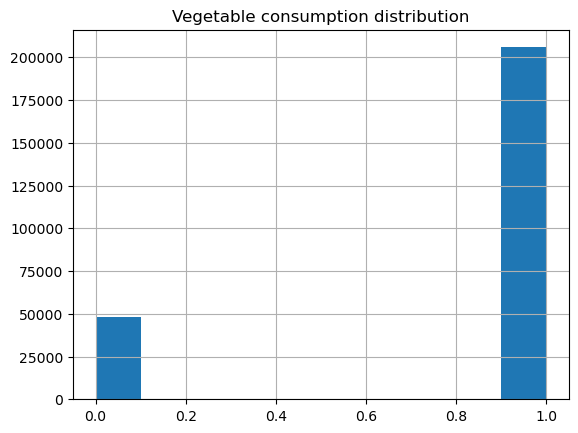

In [23]:
# plot the histogram of vegetable consumption
df['Veggies'].hist()
plt.title('Vegetable consumption distribution')
plt.show()

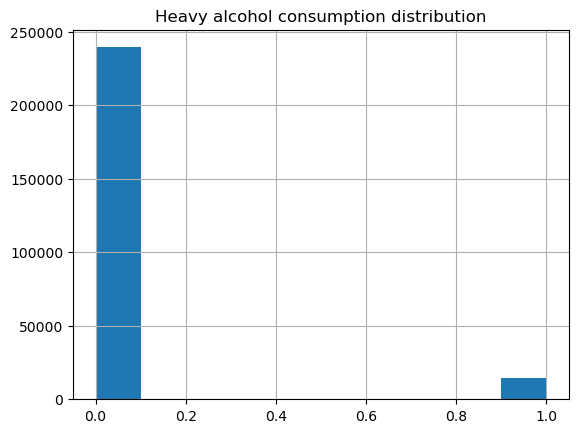

In [24]:
# plot the histogram of Heavy alcohol consumption
df['HvyAlcoholConsump'].hist()  
plt.title('Heavy alcohol consumption distribution')
plt.show()

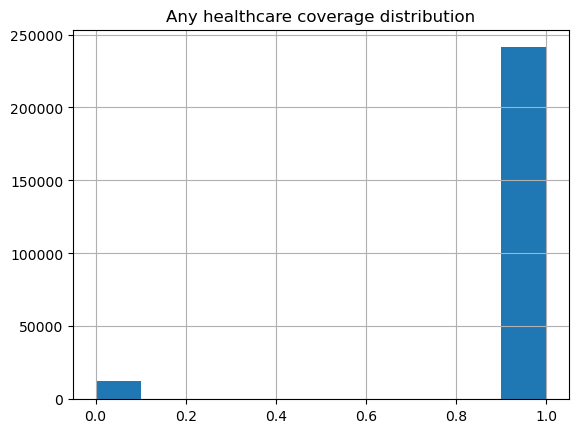

In [25]:
# plot the histogram of any healthcare coverage 
df['AnyHealthcare'].hist()
plt.title('Any healthcare coverage distribution')
plt.show()

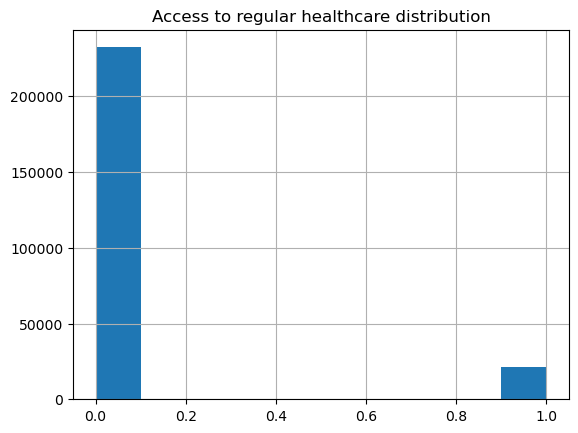

In [26]:
# plot the histogram of access to regular healthcare
df['NoDocbcCost'].hist()    
plt.title('Access to regular healthcare distribution')
plt.show()

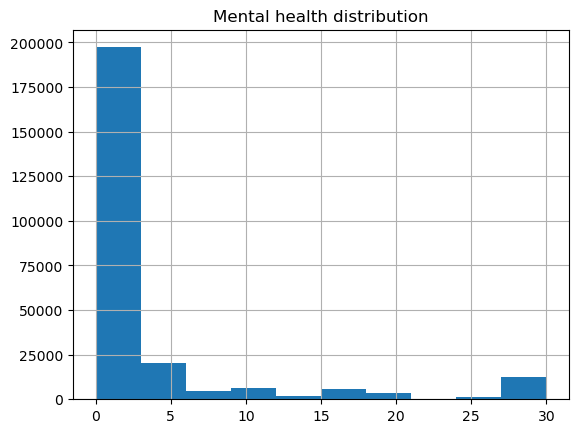

In [27]:
# plot the histogram of mental health
df['MentHlth'].hist()
plt.title('Mental health distribution')
plt.show()

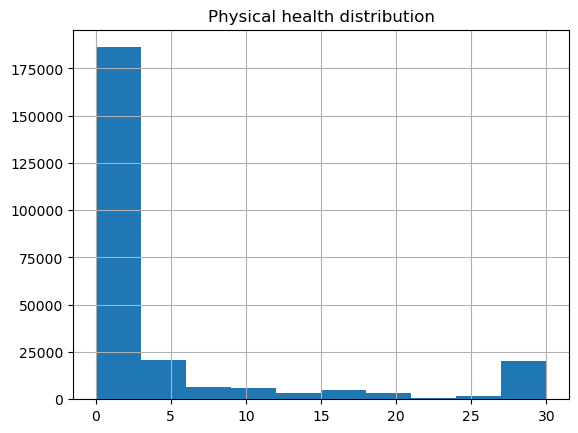

In [28]:
# plot the histogram of physical health
df['PhysHlth'].hist()
plt.title('Physical health distribution')
plt.show()

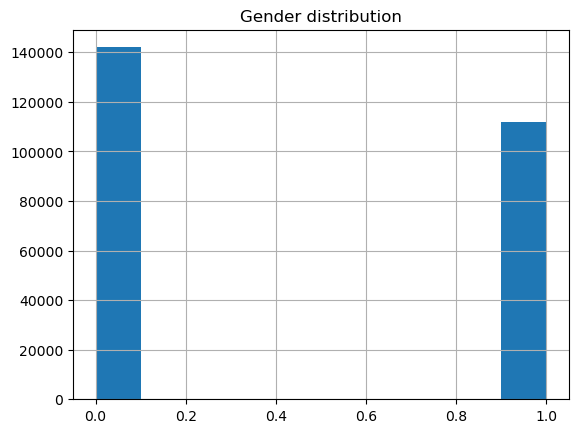

In [29]:
# plot the histogram of gender
df['Sex'].hist()
plt.title ('Gender distribution')
plt.show()      

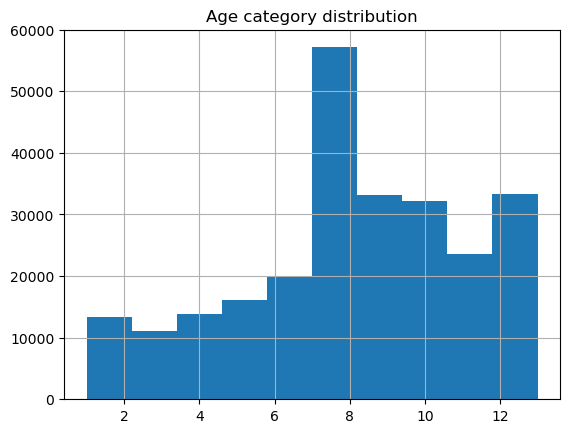

In [30]:
# Plot distribution of age category
df['Age'].hist()    
plt.title('Age category distribution')
plt.show()

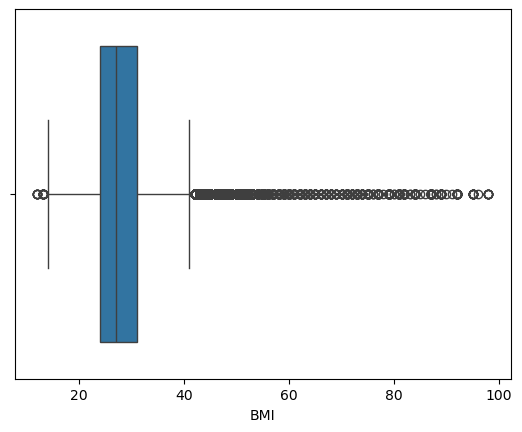

In [32]:
# Search for outliers in BMI using boxplot
sns.boxplot(x=df['BMI'])
plt.show()

BMI clearly has many outliers with very high BMI values

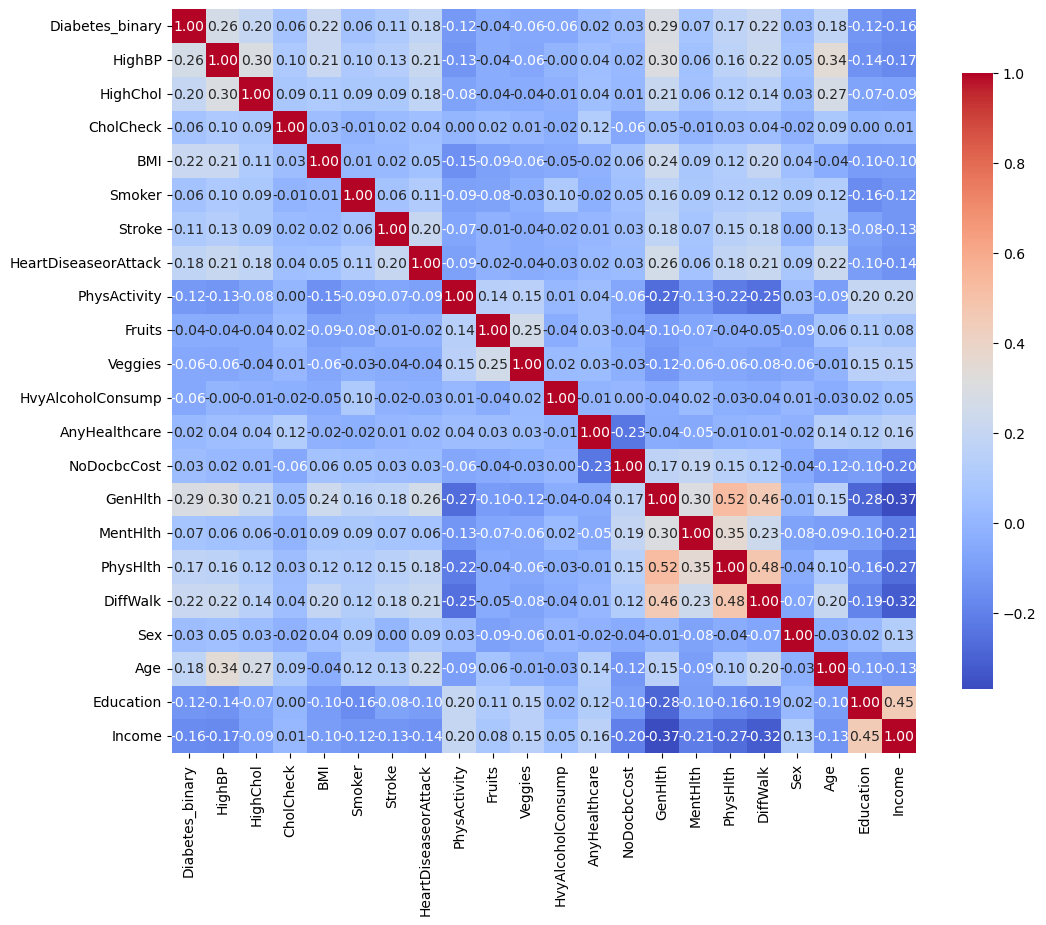

In [34]:
# Find correlation matrix
corr = df.corr()

# Display the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))    
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.show()



# **Data Preparation**

In [35]:
# Split the data into X_train, X_test, y_train and y_test
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
X_train.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
31141,0.0,1.0,1.0,20.0,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
98230,0.0,0.0,1.0,34.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,8.0,5.0,8.0
89662,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,5.0,0.0,1.0,12.0,5.0,6.0
208255,0.0,1.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,5.0,6.0,7.0
233415,0.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,12.0,4.0,6.0


In [37]:
X_test.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
219620,0.0,0.0,1.0,21.0,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,3.0,7.0,0.0,0.0,7.0,4.0,2.0
132821,1.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,0.0,13.0,6.0,6.0
151862,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,4.0,7.0
139717,0.0,0.0,1.0,27.0,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,1.0,2.0,4.0,7.0
239235,0.0,1.0,1.0,31.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,1.0,4.0,27.0,27.0,1.0,0.0,8.0,3.0,2.0


In [38]:
# Create a ColumnTransformer to apply different transformations to different column types
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns
numerical_features = X_train.select_dtypes(include=np.number).columns

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('scaler', StandardScaler(), numerical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) as they are
)

In [39]:
# Create a pipepline that does the following: 1) Uses onehotencoder to encode categorical variables in df, scales numerical variables, then performs Logistic regression .
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, solver='saga', tol=0.1))
])

In [40]:
# Use GridSearch to build a model with the above pipeline, pipe
param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

# You can then access the best parameters and score like this:
print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Best parameters: {'model__C': 100, 'model__penalty': 'l2'}
Best cross-validation score: 0.8630213261639186


In [41]:
# show best model and its coefficients
print(grid.best_estimator_)
print(grid.best_estimator_.named_steps['model'].coef_)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index([], dtype='object')),
                                                 ('scaler', StandardScaler(),
                                                  Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object'))])),
                ('model',
                 LogisticRegression(C=100, max_iter=1000, solver='saga',
                                    tol=0.1))])
[[ 0.36556781  0.27079691  0.24756329  0.41188064  0.00292206  0.02702821
   0.06

In [42]:
best = grid.best_estimator_
model = best.named_steps['model']
pre = best.named_steps['preprocessor']

coefs = model.coef_                 # shape (1, n_features)
feature_names = pre.get_feature_names_out()

importances = coefs.ravel()         # shape (n_features,)
important_features = pd.Series(importances, index=feature_names)

# Often you want magnitude:
important_features = important_features.abs().sort_values(ascending=False)
print(important_features)
# Plot the important features
plt.figure(figsize=(10, 6))

scaler__GenHlth                 0.568686
scaler__BMI                     0.411881
scaler__Age                     0.370558
scaler__HighBP                  0.365568
scaler__HighChol                0.270797
scaler__CholCheck               0.247563
scaler__HvyAlcoholConsump       0.176392
scaler__Sex                     0.136044
scaler__Income                  0.114598
scaler__HeartDiseaseorAttack    0.066062
scaler__PhysHlth                0.060632
scaler__DiffWalk                0.045446
scaler__Stroke                  0.027028
scaler__MentHlth                0.024748
scaler__PhysActivity            0.023134
scaler__Education               0.018885
scaler__Fruits                  0.015694
scaler__AnyHealthcare           0.009331
scaler__Veggies                 0.009158
scaler__Smoker                  0.002922
scaler__NoDocbcCost             0.001920
dtype: float64


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [43]:
important_features.head(20)

scaler__GenHlth                 0.568686
scaler__BMI                     0.411881
scaler__Age                     0.370558
scaler__HighBP                  0.365568
scaler__HighChol                0.270797
scaler__CholCheck               0.247563
scaler__HvyAlcoholConsump       0.176392
scaler__Sex                     0.136044
scaler__Income                  0.114598
scaler__HeartDiseaseorAttack    0.066062
scaler__PhysHlth                0.060632
scaler__DiffWalk                0.045446
scaler__Stroke                  0.027028
scaler__MentHlth                0.024748
scaler__PhysActivity            0.023134
scaler__Education               0.018885
scaler__Fruits                  0.015694
scaler__AnyHealthcare           0.009331
scaler__Veggies                 0.009158
scaler__Smoker                  0.002922
dtype: float64

In [45]:
from sklearn.inspection import permutation_importance

# Calculate the permutation importance using the fitted pipeline
results = permutation_importance(grid.best_estimator_, X_test, y_test)

# Use the original feature names from X_test
importances = pd.DataFrame(
	data=results.importances_mean,
	index=X_test.columns,
	columns=['Importance']
).sort_values(by='Importance', ascending=False)
print(importances)

                        Importance
BMI                   7.485809e-03
GenHlth               6.133712e-03
HighChol              2.467676e-03
HighBP                2.306055e-03
Age                   2.089246e-03
HvyAlcoholConsump     7.883948e-04
DiffWalk              4.730369e-04
Income                4.690949e-04
CholCheck             3.035320e-04
PhysHlth              2.877641e-04
Education             1.970987e-04
Sex                   1.852728e-04
Veggies               1.734469e-04
Fruits                1.182592e-04
HeartDiseaseorAttack  9.066541e-05
Smoker                3.547777e-05
AnyHealthcare         2.365184e-05
PhysActivity         -2.220446e-17
MentHlth             -3.941974e-06
NoDocbcCost          -3.941974e-06
Stroke               -8.278146e-05


In [47]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

best = grid.best_estimator_
model = best.named_steps['model']

# choose your positive class explicitly
positive = 1.0   # <- change if your "positive" is different

# Predictions
y_pred = grid.predict(X_test)

# Find the column index in predict_proba corresponding to the positive class
pos_idx = np.where(model.classes_ == positive)[0][0]
y_score = grid.predict_proba(X_test)[:, pos_idx]

# Metrics (explicitly set pos_label for binary string labels)
lr_f1 = f1_score(y_test, y_pred, pos_label=positive)
lr_precision = precision_score(y_test, y_pred, pos_label=positive)
lr_recall = recall_score(y_test, y_pred, pos_label=positive)
lr_auc = roc_auc_score(y_test, y_score)                    # y_score is prob of "positive"
lr_acc = accuracy_score(y_test, y_pred)

print("F1:", lr_f1)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("AUC:", lr_auc)
print("Accuracy:", lr_acc)
# Plot the ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=positive)
plt.figure(figsize=(8, 6))


F1: 0.25274725274725274
Precision: 0.5468378506894912
Recall: 0.16435615263684436
AUC: 0.8264042201061154
Accuracy: 0.8659728792179123


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

## RandomForest model

In [48]:
# Now build a pipeline that uses RandomForest classifier
rf_pipe = Pipeline([
    ('preprocessor2', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])


In [49]:
# Define the parameter grid
param_grid = {
    'model__n_estimators': [50, 100, 200],  # Number of trees in the forest
    'model__max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'model__min_samples_split': [2, 5, 10],  # Minimum samples required to split a node
    'model__min_samples_leaf': [1, 2, 4],    # Minimum samples required at a leaf node
    'model__bootstrap': [True, False]        # Whether bootstrap samples are used
}

grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='accuracy', verbose=3, n_jobs=-1)
grid.fit(X_train, y_train)

# You can then access the best parameters and score like this:
print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters: {'model__bootstrap': True, 'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best cross-validation score: 0.8658447630057668


F1: 0.22324829735657392
Precision: 0.5804321728691476
Recall: 0.13820208660854652
AUC: 0.8264578892484102
Accuracy: 0.867372280037843


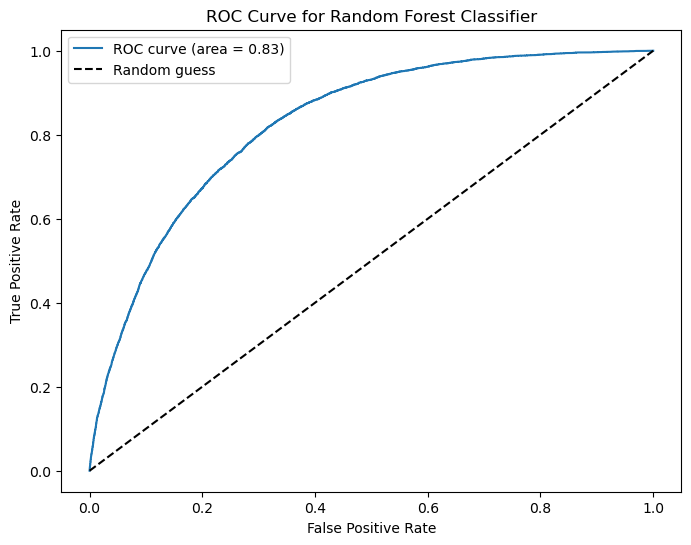

In [50]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

best = grid.best_estimator_
model = best.named_steps['model']

# choose your positive class explicitly
positive = 1.0

# Predictions
y_pred = grid.predict(X_test)

# Find the column index in predict_proba corresponding to the positive class
pos_idx = np.where(model.classes_ == positive)[0][0]
y_score = grid.predict_proba(X_test)[:, pos_idx]

# Metrics (explicitly set pos_label for binary string labels)
rf_f1 = f1_score(y_test, y_pred, pos_label=positive)
rf_precision = precision_score(y_test, y_pred, pos_label=positive)
rf_recall = recall_score(y_test, y_pred, pos_label=positive)
rf_auc = roc_auc_score(y_test, y_score)                    # y_score is prob of "positive"
rf_acc = accuracy_score(y_test, y_pred)

print("F1:", rf_f1)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("AUC:", rf_auc)
print("Accuracy:", rf_acc)
# Plot the ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label=positive)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(rf_auc))
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest Classifier')
plt.legend()
plt.show()

In [51]:
from sklearn.inspection import permutation_importance

# Calculate the permutation importance using the fitted pipeline
results = permutation_importance(grid.best_estimator_, X_test, y_test)

# Use the original feature names from X_test
importances = pd.DataFrame(
	data=results.importances_mean,
	index=X_test.columns,
	columns=['Importance']
).sort_values(by='Importance', ascending=False)
print(importances)

                      Importance
BMI                     0.005984
GenHlth                 0.004198
HighBP                  0.002523
HighChol                0.002227
Age                     0.001510
DiffWalk                0.000690
PhysHlth                0.000635
HvyAlcoholConsump       0.000631
HeartDiseaseorAttack    0.000607
MentHlth                0.000497
Income                  0.000442
Sex                     0.000307
Education               0.000142
CholCheck               0.000095
AnyHealthcare           0.000083
Veggies                 0.000083
NoDocbcCost             0.000051
Stroke                  0.000024
Fruits                 -0.000008
Smoker                 -0.000075
PhysActivity           -0.000371


In [52]:
# Compare the performance of different models and show the results in a table like the below table
#                **Model F1 Score Precision    Recall       AUC  Accuracy
#        Random Forest  0.343662   0.675277  0.230479  0.804651  0.885372
#  Logistic Regression  0.331439   0.667939  0.220403  0.795218  0.884224

print("                **Model F1 Score Precision    Recall       AUC  Accuracy")
print("        Random Forest %0.6f   %0.6f  %0.6f  %0.6f  %0.6f" % (rf_f1, rf_precision, rf_recall, rf_auc, rf_acc))
print("  Logistic Regression %0.6f   %0.6f  %0.6f  %0.6f  %0.6f" % (lr_f1, lr_precision, lr_recall, lr_auc, lr_acc))




                **Model F1 Score Precision    Recall       AUC  Accuracy
        Random Forest 0.223248   0.580432  0.138202  0.826458  0.867372
  Logistic Regression 0.252747   0.546838  0.164356  0.826404  0.865973
